#**<font color="yellow">UPDATE CSV TO GET LATEST DATA depending on workshop timing</font>**

# Intro to Quantitative Finance Workshop

##Setup

Import CSVs from yahoo finance.

In [30]:
import yfinance as yf
import pandas as pd

data = yf.download(
    ["V", "MA"],
    start="2020-01-01",
    end="2026-09-25",
    auto_adjust=True
)["Close"]

data = data.dropna()
data.index.name = "Date"

data.to_csv("V_MA.csv")

[*********************100%***********************]  2 of 2 completed


In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("default")

# Load the Data

We'll use historical prices for two related companies.

* Mastercard (`MA`)
* Visa (`V`)

The CSV contains:

```text
Date,MA,V
2020-01-02,54.12,135.67
2020-01-03,54.42,136.12
...
```

In [32]:
df = pd.read_csv("V_MA.csv")

df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date")

df = df.set_index("Date")

df.head()

,MA,V
Date,,
2020-01-02,291.906769,182.092773
2020-01-03,289.058685,180.644547
2020-01-06,289.828522,180.253983
2020-01-07,288.847076,179.777588
2020-01-08,293.943726,182.854996


# Look at the Two Stocks
First, let's see how the two stocks have moved over time.

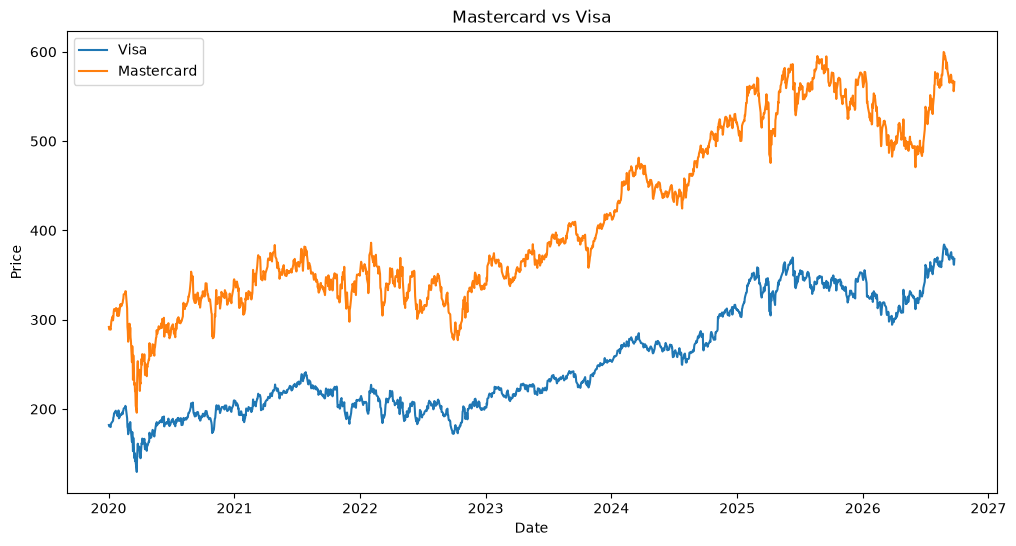

In [33]:
plt.figure(figsize=(12, 6))

plt.plot(df["V"], label="Visa")
plt.plot(df["MA"], label="Mastercard")

plt.title("Mastercard vs Visa")
plt.xlabel("Date")
plt.ylabel("Price")

plt.legend()
plt.show()

### Question

Do these stocks appear to move together?

We're not trying to predict whether either stock goes up or down.

We're interested in whether they **move relative to one another**.


# Normalize the Prices

Mastercard and Visa have different stock prices, so let's pretend both stocks started at $100 to better understand their relationship **relative to each other**

In [34]:
df["V_normalized"] = df["V"] / df["V"].iloc[0] * 100
df["MA_normalized"] = df["MA"] / df["MA"].iloc[0] * 100

Now plot them.

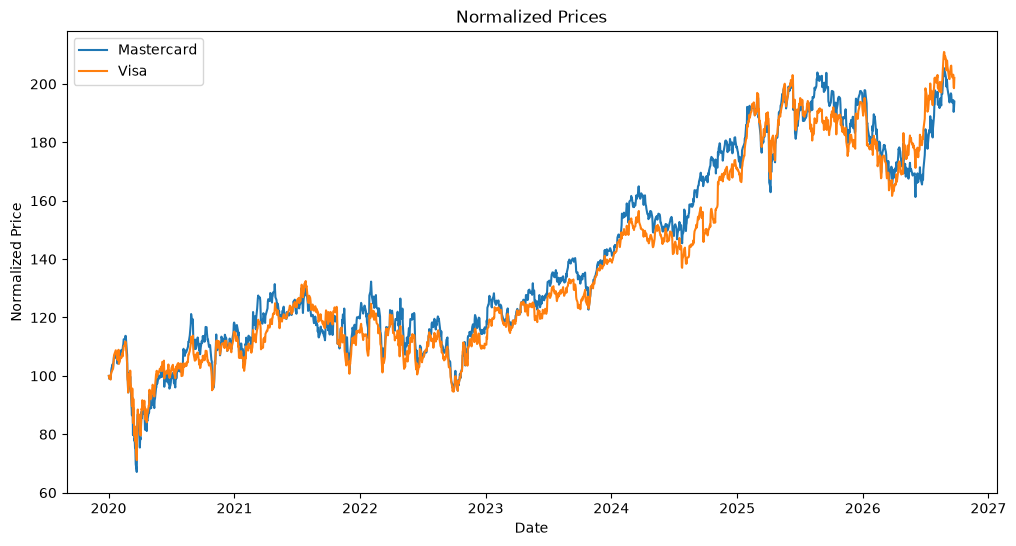

In [35]:
plt.figure(figsize=(12, 6))

plt.plot(df["MA_normalized"], label="Mastercard")
plt.plot(df["V_normalized"], label="Visa")

plt.title("Normalized Prices")
plt.xlabel("Date")
plt.ylabel("Normalized Price")

plt.legend()
plt.show()

Now both stocks start at exactly 100.

This makes their relative movements much easier to compare.

# Calculate the Spread

Let's create our first quantitative feature.

The **spread** is simply the difference between the two normalized prices.

In [36]:
df["spread"] = df["MA_normalized"] - df["V_normalized"]

Plot it:

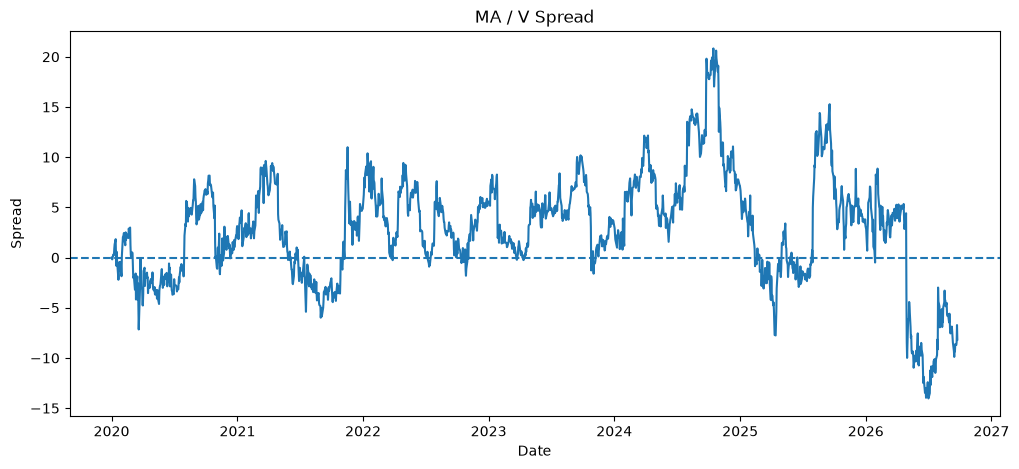

In [37]:
plt.figure(figsize=(12, 5))

plt.plot(df["spread"])

plt.axhline(0, linestyle="--")

plt.title("MA / V Spread")
plt.xlabel("Date")
plt.ylabel("Spread")

plt.show()

#**<font color="yellow"> WRITE THIS ON WHITEBOARD during workshop:</font>**

<font color="yellow">MASTERCARD-VISA SPREAD</font>

<font color="yellow">SPREAD HIGH = mastercard price UNUSUALLY HIGHER than visa price</font>

<font color="yellow">SPREAD LOW = mastercard price UNUSUALLY LOWER than visa price</font>

### What are we looking for?
If the spread normally stays relatively close to zero but occasionally becomes very large or very small, those could be interesting situations.

What happens when the spread becomes very large or very small? What direction does the spread move in after?

We can use this unusual behavior to our advantage.

# Measure What "Unusual" Means

A spread of 3 might be huge in one dataset and completely normal in another.

So instead of using an arbitrary number, we'll compare the current spread to its recent history.

We'll calculate:

* rolling average (avg spread in the last 30 days)
* rolling standard deviation (avg std in last 30 days)

In [38]:
WINDOW = 30

df["spread_mean"] = (df["spread"].rolling(WINDOW).mean())

df["spread_std"] = (df["spread"].rolling(WINDOW).std())

# Calculate the Z-Score

The z-score tells us roughly how unusual the current spread is.
(Z-score is how far something is from the average, measure in standard deviations)

In [39]:
df["z_score"] = ((df["spread"] - df["spread_mean"])/ df["spread_std"])

Plot it:

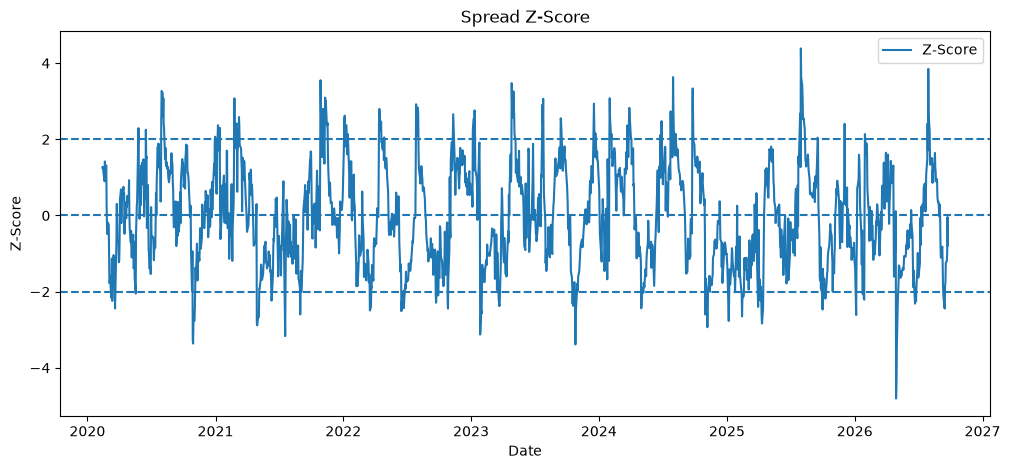

In [40]:
plt.figure(figsize=(12, 5))

plt.plot(df["z_score"], label="Z-Score")

plt.axhline(0, linestyle="--")
plt.axhline(2, linestyle="--")
plt.axhline(-2, linestyle="--")

plt.title("Spread Z-Score")
plt.xlabel("Date")
plt.ylabel("Z-Score")

plt.legend()
plt.show()

Think of the z-score like this:

```text
z = 0

The spread is normal.


z = +1

The spread is somewhat high (unusual), MA price higher than V.


z = +2

The spread is very high (very unusual).


z = -2

The spread is very low (very unusual) in the other direction (MA price lower than V)
```

# Our Trading Hypothesis

Now we need to make an actual trading algorithm.

Our hypothesis is:

> When two related assets move unusually far apart, they eventually move back toward one another.

This is called **mean reversion**.

We'll create three possible states:

```text
+1  → Buy MA / Sell V

 0  → Do nothing

-1  → Sell MA / Buy V
```

Our rules:

```text
If z-score < -2:

    MA is unusually cheap relative to V

    Buy MA
    Sell V


If z-score > +2:

    MA is unusually expensive relative to V

    Sell MA
    Buy V


Otherwise:

    Do nothing
```

---

# Turn the Idea Into Code

In [41]:
df["signal"] = 0

# spread is LOW, we think it will go back UP
df.loc[df["z_score"] < -2, "signal"] = 1

# spread is HIGH, we think it will go back DOWN
df.loc[df["z_score"] > 2, "signal"] = -1

Now let's look at our signals.

In [42]:
df["signal"].value_counts()

signal
 0    1497
-1     105
 1      89
Name: count, dtype: int64

We can also visualize them.

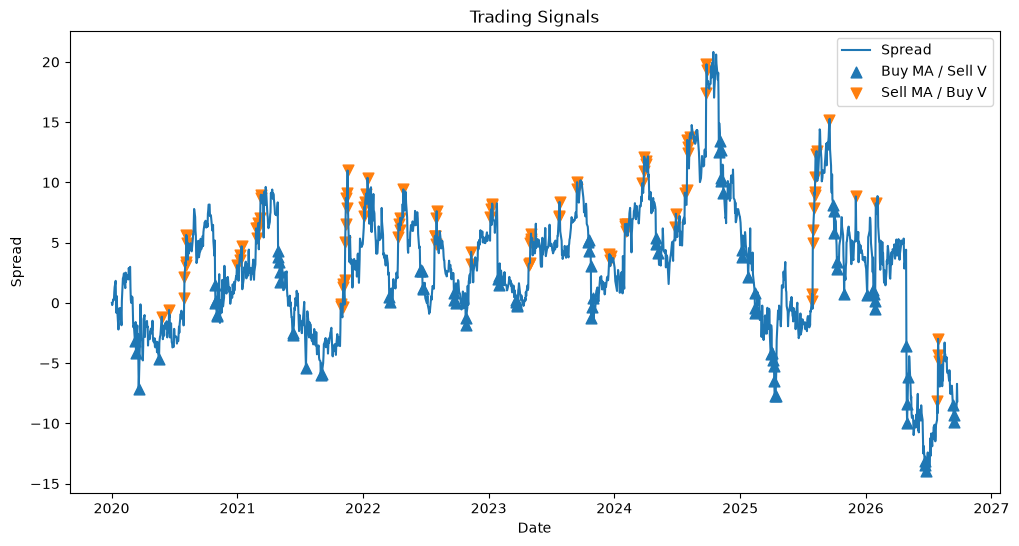

In [43]:
plt.figure(figsize=(12, 6))

plt.plot(df["spread"],label="Spread")

buy_signals = df[df["signal"] == 1]
sell_signals = df[df["signal"] == -1]

plt.scatter(
    buy_signals.index,
    buy_signals["spread"],
    marker="^",
    s=60,
    label="Buy MA / Sell V"
)

plt.scatter(
    sell_signals.index,
    sell_signals["spread"],
    marker="v",
    s=60,
    label="Sell MA / Buy V"
)

plt.title("Trading Signals")
plt.xlabel("Date")
plt.ylabel("Spread")

plt.legend()
plt.show()

*Most of the time we are doing nothing because the z score is not +2/-2. Most of the time, the spread is not unusual!

# Now We Actually Backtest It

How do we know if this is a good strategy in practice?

We want to ask:

**"If we had actually followed these rules in the past, what would have happened?"**

First, calculate daily returns.

In [44]:
df["MA_return"] = df["MA"].pct_change()  #.pct_change() calculates daily percentage return = (today's price - yesterday's price) / yesterday's price
df["V_return"] = df["V"].pct_change()


Our strategy takes the opposite position in the two stocks.

If:

```text
signal = +1
```

we are:

```text
LONG MA
SHORT V
```

Therefore:

In [45]:
df["strategy_return"] = (
    df["signal"].shift(1)  # this will be 1 or -1
    * (df["MA_return"] - df["V_return"])  # when signal is 1, we are buying MA & selling V
    )                                       # when signal is -1, this is effectively V_return - MA_return (since we are LONG V & SHORT MA)


The `.shift(1)` means we use **yesterday's signal to determine today's position**.

Otherwise, we'd use information from the future.

# Calculate Cumulative Returns

Now let's see how much money our strategy would have made.

In [46]:
df["strategy_growth"] = (
    # 1 + df["strategy_return"] turns percents into growth multiplier (ex. 2% becomes 1.02, -1% becomes 0.99, etc.)
    1 + df["strategy_return"].fillna(0)      #first return is NaN because no previous day to compare to, make this a 0
).cumprod() # cumulative product, multiplies growth factors as we go

.cumprod() explanation:
```text
Daily return     Growth factor

0%               1.00
+2%              1.02
-1%              0.99
+3%              1.03
```

```text
Day 1:
1.00

Day 2:
1.00 × 1.02 = 1.02

Day 3:
1.02 × 0.99 = 1.0098

Day 4:
1.0098 × 1.03 = 1.0401
```

Plot it:

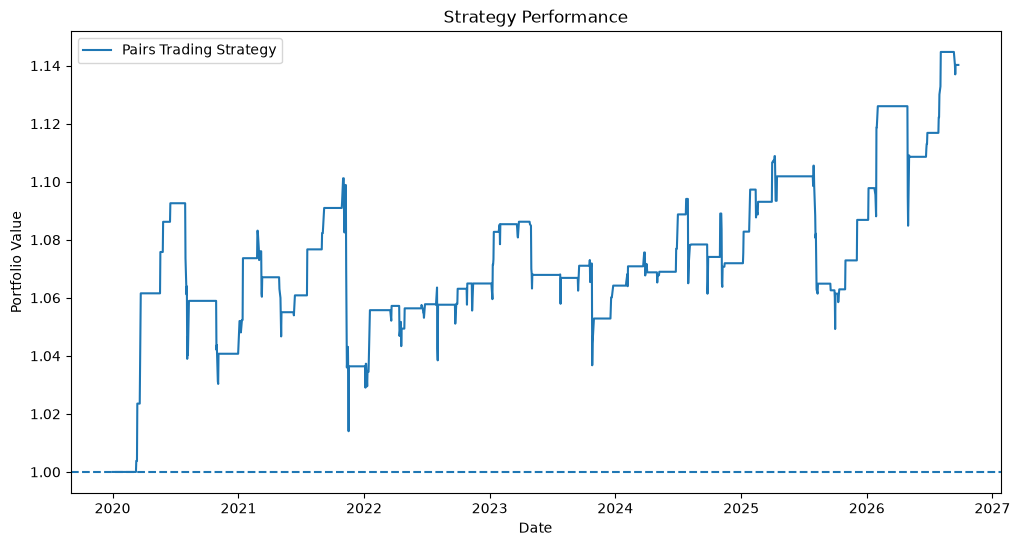

In [47]:
plt.figure(figsize=(12, 6))

plt.plot(df["strategy_growth"],label="Pairs Trading Strategy")

plt.axhline(1,linestyle="--")

plt.title("Strategy Performance")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")

plt.legend()
plt.show()

If the line ends at:

```text
1.20
```

that means:

> \$1 became approximately $1.20.

Or:

```text
20% return
```

# Compare Against a Simple Benchmark
We should never evaluate a strategy by itself.

Let's compare it against simply holding MA.

In [48]:
df["MA_growth"] = (1 + df["MA_return"].fillna(0)).cumprod()

Plot both:

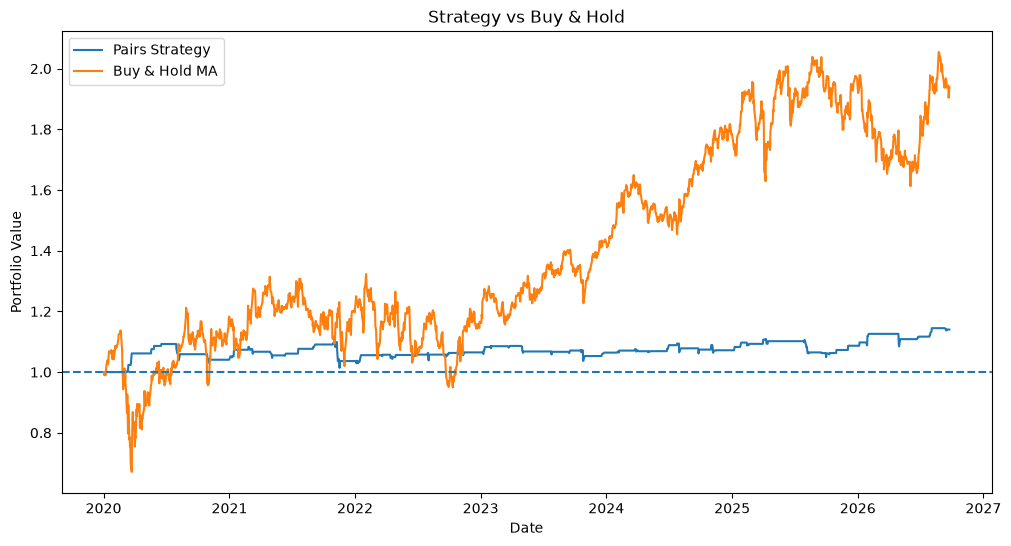

In [49]:
plt.figure(figsize=(12, 6))

plt.plot(df["strategy_growth"],label="Pairs Strategy")

plt.plot(df["MA_growth"],label="Buy & Hold MA")

plt.axhline(1,linestyle="--")

plt.title("Strategy vs Buy & Hold")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")

plt.legend()
plt.show()

# Calculate the Final Results

In [50]:
strategy_return = (
    df["strategy_growth"].iloc[-1] - 1 # - 1 to change growth multiplier back to percent (ex. 1.25 - 1 = 0.25)
)

ma_return = (df["MA_growth"].iloc[-1] - 1)

print(f"Pairs Strategy Return: {strategy_return:.2%}")
print(f"MA Buy & Hold Return: {ma_return:.2%}")


Pairs Strategy Return: 14.02%
MA Buy & Hold Return: 93.92%


For example, we might get:

```text
Pairs Strategy Return: 7.43%
MA Buy & Hold Return: 5.91%
```

Or:

```text
Pairs Strategy Return: -2.31%
MA Buy & Hold Return: 5.91%
```

# How Often Were We Right?

Let's measure whether the strategy correctly predicted the direction of the spread.

In [51]:
df["future_spread_change"] = (
    df["spread"].shift(-1) - df["spread"]   #df["spread"] is today, df["spread"].shift(-1) is tmrw
)

We only care about days where we actually made a prediction.

In [52]:
trades = df[df["signal"] != 0].copy()

Determine whether the spread moved in the direction we expected.

In [53]:
trades["correct"] = (
    trades["signal"] * trades["future_spread_change"] > 0 #if signal & future spread change have same sign, we were correct
)

Calculate accuracy:

In [54]:
accuracy = trades["correct"].mean()

print(f"Strategy Accuracy: {accuracy:.2%}")

Strategy Accuracy: 55.15%


A good result might be:

```text
Strategy Accuracy: 52.4%
```

We will never be right 90% of the time.

We are looking for a repeatable edge that is **slightly better than random**

#Train/Test Split

What if we looked at all the historical data while designing our strategy?

Then tested it on that same data?

We might have accidentally designed a strategy that **overfits** for the past.

In [55]:
split = int(len(df) * 0.7)

train = df.iloc[:split].copy()
test = df.iloc[split:].copy()

print("Training observations:", len(train))
print("Testing observations:", len(test))

Training observations: 1183
Testing observations: 508


##Test the Strategy on Unseen Data

Evaluate the strategy separately on just the testing period.

In [56]:
test_strategy_return = (test["strategy_return"].fillna(0))

test_growth = (1 + test_strategy_return).cumprod()

Plot it:

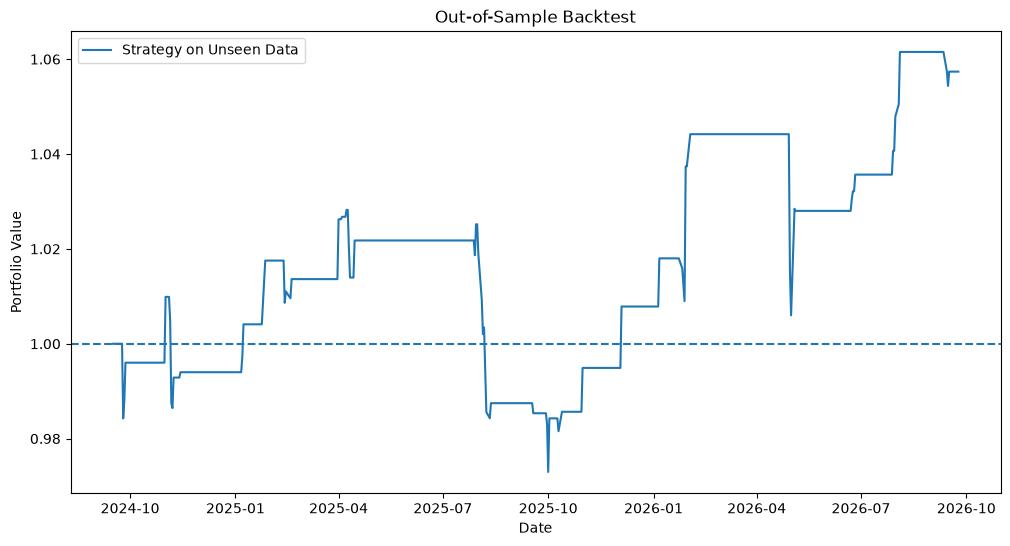

In [57]:
plt.figure(figsize=(12, 6))

plt.plot(test_growth,label="Strategy on Unseen Data")

plt.axhline(1,linestyle="--")

plt.title("Out-of-Sample Backtest")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")

plt.legend()
plt.show()

Calculate the return:

In [58]:
test_return = test_growth.iloc[-1] - 1

print(f"Out-of-Sample Return: {test_return:.2%}")

Out-of-Sample Return: 5.74%


#What We Actually Built

We started with:

```text
Two stocks
```

and built:

```text
Two stocks
      ↓
Normalize prices
      ↓
Calculate spread
      ↓
Measure unusual behavior
      ↓
Z-score
      ↓
Trading signal
      ↓
Backtest
      ↓
Evaluate performance
      ↓
Test on unseen data
```

This is a simplified version of a real quantitative research pipeline.

Key Question:

> **"When two things that normally move together suddenly don't, is that information useful?"**

And then we used data to test the hypothesis.



# Workshop Simplification

This is **not  true arbitrage**, there is still risk with this strategy.

The strategy is a simplified form of **pairs trading / relative-value trading**.

There is no guarantee that the prices will converge (not risk free).

The relationship between two assets can break permanently, which would break the strategy (permanently).




---



## <font color="yellow"> If extra time: </font>

#Experiment!

Now you try changing the strategy.

Try changing:

```python
WINDOW = 30
```

to:

```python
WINDOW = 10
```

or:

```python
WINDOW = 60
```

Then change:

```python
z_score > 2
```

to:

```python
z_score > 1.5
```

or:

```python
z_score > 2.5
```

Ask:

### Which strategy makes the most money?

Then ask the much more important question:

### Which strategy works best on data it hasn't seen?

---

#Challenge

Your team has 20 minutes.

Choose one pair:

```text
MA / V
KO / PEP
GS / MS
XOM / CVX
```

Your goal:

> **Build a strategy that finds a repeatable edge in the relationship between two assets.**

You can change:

* the rolling window
* the z-score threshold
* the assets
* the entry conditions
* the exit conditions

But you must report:

```text
1. Your strategy

2. Your training performance

3. Your testing performance

4. Your prediction accuracy

5. Why you think it works
```


# Discussion

Share your strategy!

Whose stragegy performed the best on their test set (best out of sample return)? How does this compare to the team with highest accuracy?